# Custom Modules

Beyond `Predict` and `ChainOfThought` DSPy provides both built-in modules allows to build custom ones.

We can think about two types of DSPy modules: (1) making a single LM call and encoding a prompting technique (2) more complex workflows with potentially multiple LM requests, logic, tool calls.

In [1]:
import dspy
import os

In [8]:
lm = dspy.LM(
    model="hosted_vllm/RadixArk/Qwen3.8-27B-NVFP4",
    api_base="http://localhost:30000/v1",
    # api_key=os.getenv("OPENROUTER_API_KEY"),
)
dspy.configure(lm=lm)

The simplest `Predict` wrapper looks like this:

In [9]:
class SimpleModule(dspy.Module):
   def __init__(self):
      super().__init__()
      self.query = dspy.Predict("input_query -> output")
 
   def forward(self, input_query):
      return self.query(input_query=input_query)
 
prog = SimpleModule()
prog(input_query="What is the capital of France?")

Prediction(
    output='The capital of France is Paris.'
)

Usually, almost all code goes into `forward`. `forward` must include all the fields we use in signatures in `__init__`. `forward` will be used as `__call__`, hence when we call the program we must provide all fields as well.

We usually define a signature directly in the module constructor. However, we can also accept it from the outside to make our module more generic. It is rarely needed though.

```python
class MoreComplexModule(dspy.Module):
  def __init__(self, **kwargs):
    super().__init__()
    self.module1 = dspy.Predict(signature1)
    self.module2 = dspy.Predict(signature2)
 
  def forward(self, input1, input2):
    x1 = preprocess(input1)
    x2 = preprocess(input2)
    x = self.module1(input1=x1, input2=x2)
    x = process_intermediate_results(x)
    x = self.module2(input=x)
    x = final_processing(x)
    return dspy.Prediction(x=x)
 
mod = MoreComplexModule()
mod(input1="this is the first input", input2="this is the second input")
```

Within `forward()` methods, it’s also common to collect additional information that’s necessary to make the LM calls or to compose the final results. Examples include making queries to databases, calling remote APIs, scraping websites, and so on.

# Built-in Modules

## Note on ChainOfThoughts

**DSPy’s `ChainOfThought` is modifies the signature by adding a `reasoning` output field before the final answer.

With a native reasoning model:

* **Native reasoning** controls how the model internally computes the answer.
* **DSPy `ChainOfThought`** asks the model to additionally produce a structured, visible rationale that DSPy can parse, evaluate, and optimize.

They can work together, but may be redundant: the model might reason internally and then generate another explanation for DSPy, increasing tokens and latency. That visible explanation is also **not necessarily the model’s actual hidden reasoning**.

Practically, start with `dspy.Predict` for strong reasoning models. Use `dspy.ChainOfThought` only when evaluations show better accuracy, or when an explicit rationale is useful for debugging or downstream processing.


In [17]:
prog_cot = dspy.ChainOfThought("input_query -> output")

In [18]:
prog_cot(input_query="What is the capital of France?")

Prediction(
    reasoning='The question asks for the capital of France. The well-known and correct answer is Paris.',
    output='Paris'
)

## MultiChainComparison

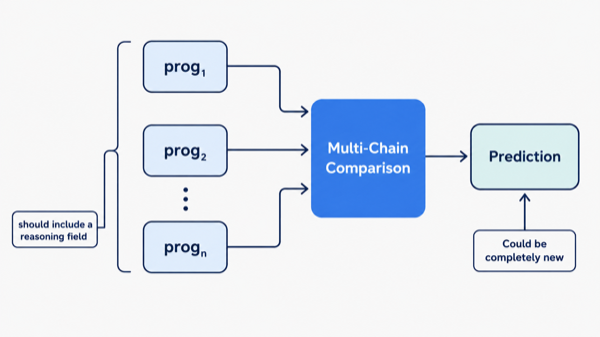

## Refine 

[Refine](https://dspy.ai/api/modules/Refine/) is probably the most complex of all the modules. It will use an extra LM call and a `reward_func`. I can imagine it could be useful for keep rewriting, for example, a SQL query, or getting specific response lengths, or valid format, etc. Very useful one for test-time refinement.